# **Assignment 1**
##### Name: Isidora Gautier
##### Student Number: 48622613

1. I used the GENAI tool, i.e., ChatGPT, to check my grammar, identify errors, and understand how to change data in Excel to the YYYY-MM-DD format (I used the function to convert dates and also to identify the errors). Additionally, I used it to explore other ways to plot graphs in the same window, making it easier to analyze the data
2. I cleared some outputs to reduce the number of pages. The document originally had 55 pages, and I couldn't reduce it to 20 without deleting important data. Some of the plot code is too large.


In [184]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from datetime import datetime
## Im importing at the begining of the code all the packages that could be used during the assignment.
import warnings
warnings.filterwarnings("ignore") # to hide the warning messages

## **Section 1 Data Cleansing**



#### **1.1 First Step - Understand the data:**
In this section used different functions to understand the data, how many columns, rows, nulls, data types and column names.

In [7]:
cust=pd.read_csv('customer_shopping_data.csv')

In [8]:
cust.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,8/05/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,11/09/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,5/16/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,10/24/2021,Kanyon


In [ ]:
cust.info()

In [10]:
cust.shape

(99461, 10)

In [11]:
missing_count = cust.isnull().sum()
print("Missing values per column:\n",missing_count)

Missing values per column:
 invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             2
payment_method    1
invoice_date      0
shopping_mall     0
dtype: int64


**1.1 Comments:**
 1. The data originally has 10 columns and 99461 rows
 2. 3 Columns have quantitative data (Age, Quantity, Price)
 3. Invoice Date is stored as a Object not Data type.
 4. There are 3 missing values, 2 in price and 1 in payment method


#### **1.2 Second Step - Elimintate or replace missing rows**

As there are missing just 2 price rows and one payment method, I can just drop those rows as we have a big amount of rows and loosing just 3 would not be significant. (les than 0.001% of the rows)


In [ ]:
cust_wo_na = cust.dropna()
missing_count_2=cust_wo_na.isnull().sum()
print("Missing values per column:\n",missing_count_2)

In [16]:
cust_wo_na.shape

(99458, 10)

#### **1.3 Third Step - Data Conversion**
1. Date conversions: there are some that are not in YYYY/MM/DD 
2. Data correction for Gender, Category and Payment Method
3. Eliminate duplicates, only for the same invoice, all others can be repeated values

**1.3.1 Date conversion:**

1. First I try to understand how many lines do have errors when I try to convert the invoice date column in date type.
2. Create 2 functions, one to convert different kinds of dates as serial numbers in date type.
   and the second one to convert all dates in the same format.

In [ ]:
cust_wo_na['parsed_date'] = pd.to_datetime(cust_wo_na['invoice_date'], errors='coerce')

# First i create incorrect_dates to identify rows where 'parsed_date' is NaT (those are the dates that
#Cannot be converted to datetime type)
incorrect_dates = cust_wo_na[cust_wo_na['parsed_date'].isna()]

# Show the rows with incorrect dates
print("Rows with incorrect date formats:")
print(incorrect_dates);

In [ ]:
import pandas as pd
from datetime import datetime

def parse_date(value):
    # Convert various date formats and serial dates to a datetime object
    if isinstance(value, str):
        # Try parsing date formats
        for fmt in ('%m/%d/%Y', '%d/%m/%Y'):
            try:
                return datetime.strptime(value, fmt)
            except ValueError:
                continue
        # Handle serial dates (e.g., Excel)
        try:
            if value.replace('.', '', 1).isdigit():
                base_date = datetime(1899, 12, 30)  # Excel's date correction
                return base_date + pd.to_timedelta(float(value), unit='D')
        except ValueError:
            return None
    elif isinstance(value, (int, float)):
      
        base_date = datetime(1899, 12, 30)
        return base_date + pd.to_timedelta(float(value), unit='D')
    return None

def format_date(date):
    # Convert a datetime object to the desired string format
    if isinstance(date, datetime):
        return date.strftime('%m/%d/%Y')
    return None

# Apply parsing and formatting functions
cust_wo_na['parsed_date'] = cust_wo_na['invoice_date'].apply(parse_date)
cust_wo_na['date'] = cust_wo_na['parsed_date'].apply(format_date)
print(cust_wo_na);

In [ ]:
# check some serial examples
check_rows=[13,30,49,111,235]
cust_wo_na.iloc[check_rows]


In [ ]:
cust_wo_na['date'] = pd.to_datetime(cust_wo_na['date'],format='%m/%d/%Y')

In [23]:
print(cust_wo_na['date'].dtype) # Check if the date column type now is datatime.

datetime64[ns]


In [ ]:
cust_wo_na['date'].unique() #Check the formats

**1.3.2 Data correction for Gender, Category and Payment Method**
1. I Checked with unique function to find abnormalities (that could be errors in typing)
2. I corrected with replace function the correct values
3. There was one #error# value which i could not tell which payment type was, so I decided to eliminate that row as it was only one from a large data set.

In [26]:
print(cust_wo_na['gender'].unique())
# I will correct Mal as it should be Male.

['Female' 'Male' 'Mal']


In [ ]:
cust_wo_na['gender']=cust_wo_na['gender'].replace("Mal","Male")
print(cust_wo_na['gender'].unique());

In [28]:
print(cust_wo_na['category'].unique())

['Clothing' 'Shoes' 'Books' 'Cosmetics' 'Food & Beverage' 'Toys' 'Clothi'
 'Technology' 'Toy' 'Boks' 'Souvenir' 'Shoe' 'Cosmetic' 'Tech' 'Food']


In [ ]:
corrections = {'Toy': 'Toys', 'Boks': 'Books','Shoe':'Shoes','Cosmetic':'Cosmetics','Tech':'Technology','Food':'Food & Beverage','Clothi':'Clothing'}
cust_wo_na['category']=cust_wo_na['category'].replace(corrections)
print(cust_wo_na['category'].unique())

## Here I defined a variable with all the corrections I need to do.

In [ ]:
print(cust_wo_na['age'].unique()) ## there are no values that should be replaced, it could exist someone with 99 years buying in Turkey

In [31]:
print(cust_wo_na['payment_method'].unique())

['Credit Card' 'Debit Card' 'Cash' '##error##' 'Cash Cash' 'CreditCard']


In [ ]:
corrections2={'Cash Cash':'Cash','CreditCard':'Credit Card'} # Variable with corrections
cust_wo_na['payment_method']=cust_wo_na['payment_method'].replace(corrections2)
print(cust_wo_na['payment_method'].unique())

In [33]:
cust_wo_na[cust_wo_na['payment_method']=='##error##'].shape[0] #only one error, so I will eliminate that row

1

In [ ]:
cust_2=cust_wo_na[cust_wo_na['payment_method']!='##error##']
cust_2.info()
# Now I check again the data types and the null values, there are only for parsed_date which was a 
#variable to understand the original invoice date data. 

In [ ]:
# Here im trying to understand more information about que quantity variables.
# STD is very high, it could be because the prices are really different between categories. I will check this
#later in skewness analysis.
cust_2['price'].describe()

In [144]:
print(cust_2['shopping_mall'].unique()) # just replacing Mall Istanbul to Mall of Istanbul
cust_2['shopping_mall']=cust_2['shopping_mall'].replace("Mall Istanbul","Mall of Istanbul");


['Kanyon' 'Forum Istanbul' 'Metrocity' 'Metropol AVM' 'Istinye Park'
 'Mall of Istanbul' 'Emaar Square Mall' 'Cevahir AVM' 'Viaport Outlet'
 'Zorlu Center']


In [ ]:
print(cust_2['shopping_mall'].unique()) 
cust_2.head()

In [ ]:
value_counts = cust_2['invoice_no'].value_counts()
print(value_counts) #there are only 3 duplicate values for the invoices

In [41]:
cust_3=cust_2.drop_duplicates(subset='invoice_no') #here im creating a diferent dataframe without
#the duplicate values. This will be the final data frame to perform all the analysis.


#### **1.4 Fourth Step - Histograms and Boxplots**
1. I will plot gender, age, category, quantity, price, payment method, shopping mall to check if there is anything to correct and to understand more about the data
2. Then, I will correct if there are outliers or skewness.

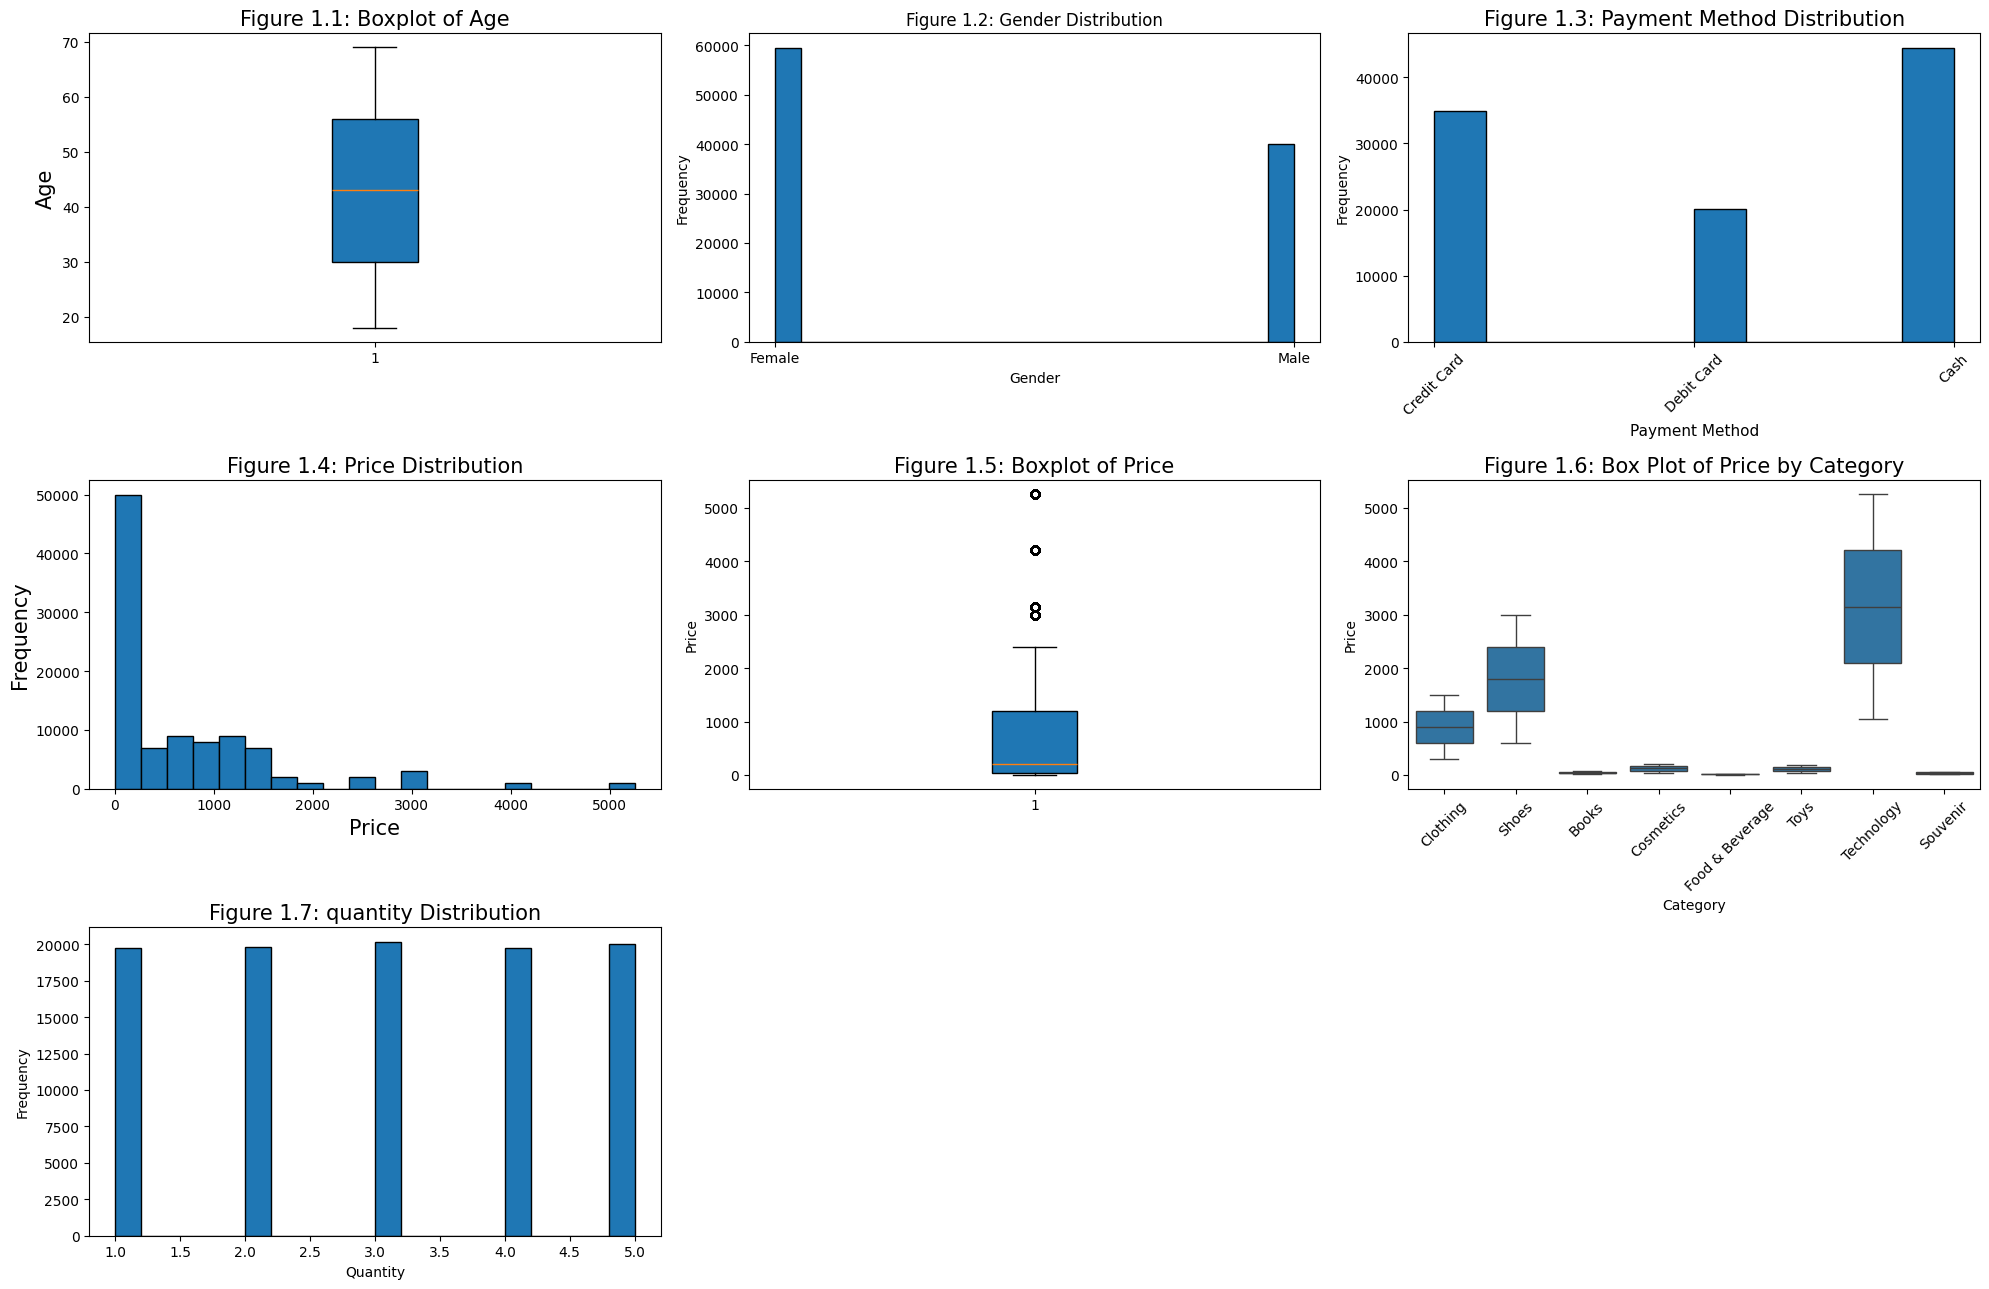

In [45]:
# I will plot all the plots in sub plots to reduce the document pages:
plt.figure(figsize=(20, 13))
plt.subplot(3, 3, 1)
plt.boxplot(cust_3['age'], patch_artist=True)
plt.title('Figure 1.1: Boxplot of Age', fontsize=15)
plt.ylabel('Age', fontsize=15);

plt.subplot(3, 3, 2)
plt.hist(cust_3['gender'], bins=20, edgecolor='black')
plt.title('Figure 1.2: Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Frequency');

plt.subplot(3, 3, 3)
plt.hist(cust_3['payment_method'], bins=10, edgecolor='black')
plt.title('Figure 1.3: Payment Method Distribution', fontsize=15)
plt.xlabel('Payment Method', fontsize=11)
plt.ylabel('Frequency', fontsize=10)
plt.xticks(rotation=45, fontsize=10);

plt.subplot(3, 3, 4)
plt.hist(cust_3['price'], bins=20, edgecolor='black')
plt.title('Figure 1.4: Price Distribution', fontsize=15)
plt.xlabel('Price', fontsize=15)
plt.ylabel('Frequency', fontsize=15)

plt.subplot(3, 3, 5)
plt.boxplot(cust_3['price'], patch_artist=True)
plt.title('Figure 1.5: Boxplot of Price', fontsize=15)
plt.ylabel('Price');

plt.subplot(3, 3, 6)
sns.boxplot(x='category', y='price', data=cust_3)
plt.title('Figure 1.6: Box Plot of Price by Category', fontsize=15)
plt.xlabel('Category', fontsize=10)
plt.ylabel('Price', fontsize=10)
plt.xticks(rotation=45, fontsize=10);

plt.subplot(3, 3, 7)
plt.hist(cust_3['quantity'], bins=20, edgecolor='black')
plt.title('Figure 1.7: quantity Distribution', fontsize=15)
plt.xlabel('Quantity', fontsize=10)
plt.ylabel('Frequency', fontsize=10);
plt.tight_layout()

Figures Comments:
1. Figure 1.1: Boxplot of Age indicates that there is no significant skewness or outliers in the age distribution, suggesting a relatively uniform distribution.
2. Figure 1.2: Gender Distribution shows that there are more females shopping in the Istanbul stores according to the dataset. No further corrections are needed.
3. Figure 1.3: Payment Method Distribution reveals that cash is the preferred payment method among customers in the sample.
4. Figure 1.4: Price Distribution shows a positive skewness. Additionally, Figure 1.5: Boxplot of Price reveals the presence of outliers. This could be attributed to varying categories and price brackets. To better understand this, I will create a boxplot by category.
5. Figure 1.6: Box Plot of Price by Category indicates that the median prices vary significantly between categories, which explains the outliers in the overall price data. However, outliers should not be present within individual categories. I will further investigate the numbers by category to confirm this.
6. Figure 1.7: Quantity Distribution shows distribution ranges from 1 to 5 and appears to be almost evenly distributed.

In [47]:
q25_price_by_category3 = cust_3.groupby('category')['price'].quantile(0.25)
q75_price_by_category3 = cust_3.groupby('category')['price'].quantile(0.75)

iqr_by_category3 = q75_price_by_category3 - q25_price_by_category3
upper_limit = cust_3.groupby('category')['price'].quantile(0.75) + 1.5 *iqr_by_category3 
max=cust_3.groupby('category')['price'].max()

print('**upper limit by category**',upper_limit)
print('**max by category**',max)


**upper limit by category** category
Books               106.05
Clothing           2100.56
Cosmetics           284.62
Food & Beverage      36.61
Shoes              4201.19
Souvenir             82.11
Technology         7350.00
Toys                250.88
Name: price, dtype: float64
**max by category** category
Books                75.75
Clothing           1500.40
Cosmetics           203.30
Food & Beverage      26.15
Shoes              3000.85
Souvenir             58.65
Technology         5250.00
Toys                179.20
Name: price, dtype: float64


Comparing the upper limit of each price by category with the max price by category and because lower limit are all negative or near 0 I can tell there are no outliers in the price data.
I will check the skewness to double check the distribution

In [49]:
cust_3.groupby('category')['price'].skew()

category
Books              0.004754
Clothing           0.001226
Cosmetics         -0.010551
Food & Beverage    0.004242
Shoes             -0.005535
Souvenir           0.030970
Technology        -0.004853
Toys              -0.016775
Name: price, dtype: float64

As all skewness by category are between -1 and 1, I can now make all my analysis by category.

## Section 2: Analysis


#### 2.1. Based on your analysis, which customer segments/categories should the shopping mall target for marketing campaigns?

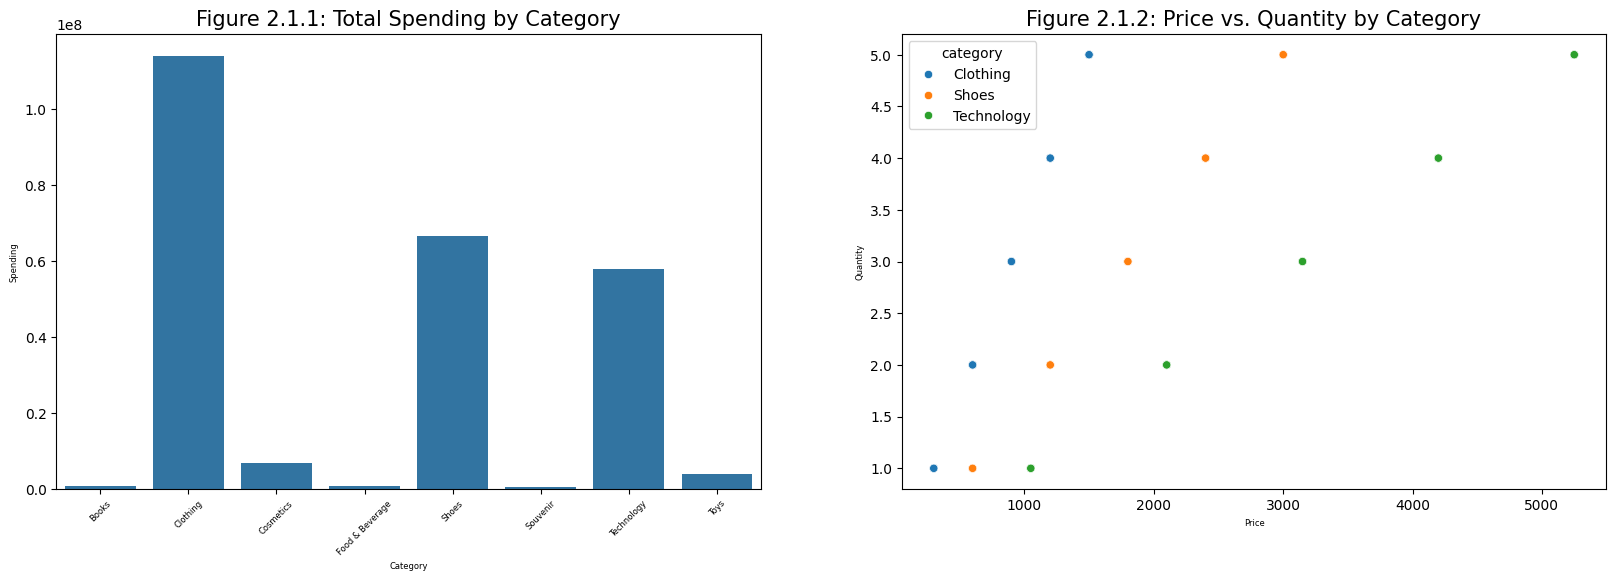

In [146]:
# Calculate total spending per category
cust_3['spending'] = cust_3['price'] * cust_3['quantity']
category_spending = cust_3.groupby('category')['spending'].sum().reset_index()

categories_to_plot = ['Clothing', 'Shoes','Technology'] # for scatterplot
filtered_cust_3 = cust_3[cust_3['category'].isin(categories_to_plot)]

plt.figure(figsize=(20, 13))

plt.subplot(2, 2, 1)
sns.barplot(x='category', y='spending', data=category_spending)
plt.title('Figure 2.1.1: Total Spending by Category', fontsize=15)
plt.xlabel('Category', fontsize=6)
plt.ylabel('Spending', fontsize=6)
plt.xticks(rotation=45, fontsize=6)

plt.subplot(2, 2, 2)
sns.scatterplot(x='price', y='quantity', hue='category', data=filtered_cust_3)
plt.title('Figure 2.1.2: Price vs. Quantity by Category', fontsize=15)
plt.xlabel('Price', fontsize=6)
plt.ylabel('Quantity', fontsize=6)
plt.show();
## The three biggest spending categories are Clothing, Shoes and Technology.

In [148]:
category_correlations = cust_3.groupby('category').apply(lambda x: x[['price', 'quantity']].corr().loc['price', 'quantity']);
print("Correlation between price and quantity by category:");
print(category_correlations);

Correlation between price and quantity by category:
category
Books              1.0
Clothing           1.0
Cosmetics          1.0
Food & Beverage    1.0
Shoes              1.0
Souvenir           1.0
Technology         1.0
Toys               1.0
dtype: float64


I used the formula they taught us in Data Science. I can tell that the quantity purchased is positively related to the price for each category. Therefore, for all categories, as the price increases, customers buy more items. So, the marketing campaigns should not focus on price reductions.

In [56]:
cust_3.groupby('category')['spending'].describe()

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
Books,4981.0,167.547260,131.909394,15.15,60.60,136.35,242.40,378.75
Clothing,34485.0,3305.413614,2597.454960,300.08,1200.32,2700.72,4801.28,7502.00
Cosmetics,15096.0,449.934575,351.881480,40.66,162.64,365.94,650.56,1016.50
Food & Beverage,14776.0,57.494251,45.385558,5.23,20.92,47.07,83.68,130.75
Shoes,10034.0,6632.793649,5181.163758,600.17,2400.68,5401.53,9602.72,15004.25
Souvenir,4999.0,127.190368,101.236358,11.73,46.92,105.57,187.68,293.25
Technology,4996.0,11581.735388,9070.511913,1050.00,4200.00,9450.00,16800.00,26250.00
Toys,10087.0,394.609521,307.505112,35.84,143.36,322.56,573.44,896.00


In [57]:
cust_3.groupby('category')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
Books,4981.0,45.568621,21.492662,15.15,30.30,45.45,60.60,75.75
Clothing,34485.0,901.066667,424.231774,300.08,600.16,900.24,1200.32,1500.40
Cosmetics,15096.0,122.445963,57.459069,40.66,81.32,121.98,162.64,203.30
Food & Beverage,14776.0,15.671948,7.422176,5.23,10.46,15.69,20.92,26.15
Shoes,10034.0,1807.388568,845.116269,600.17,1200.34,1800.51,2400.68,3000.85
Souvenir,4999.0,34.894345,16.564498,11.73,23.46,35.19,46.92,58.65
Technology,4996.0,3156.935548,1481.559805,1050.00,2100.00,3150.00,4200.00,5250.00
Toys,10087.0,107.733185,50.364844,35.84,71.68,107.52,143.36,179.20


##### Conclusion 2.1
1. **Findings:**
   - Clothing, Technology, and Shoes are the categories with the highest spending.
   - From 'Figure 2.1.2: Price vs. Quantity by Category', I can tell there is a positive correlation between price and quantity, so if the price increases, the quantity also increases.
   - The categories with the highest quantity of purchases are Clothing, Cosmetics, and Food & Beverage. However, since the average price is lower in Cosmetics and Food & Beverage, them are not the ones with the greatest spending.

2. **Conclusion:**
   I think the correct way to determine where the marketing campaigns should focus is by analyzing the revenue of each category, but since I don’t have that information, I’m assuming all categories generate the same revenue. I believe the best category to invest in, if I had to choose one, would be Technology, as it has one of the highest spending due to its higher average prices, even though it is not the most popular category. Therefore, if marketing campaigns can attract more people to buy these products, spending would increase. I would not invest in price-focused marketing campaigns, as consumers do not buy more when the price is lower.

#### 2.2. Create a box plot to compare the distribution of spending scores between male and female customers. What can you infer from the box plot about the spending behaviour of different genders?

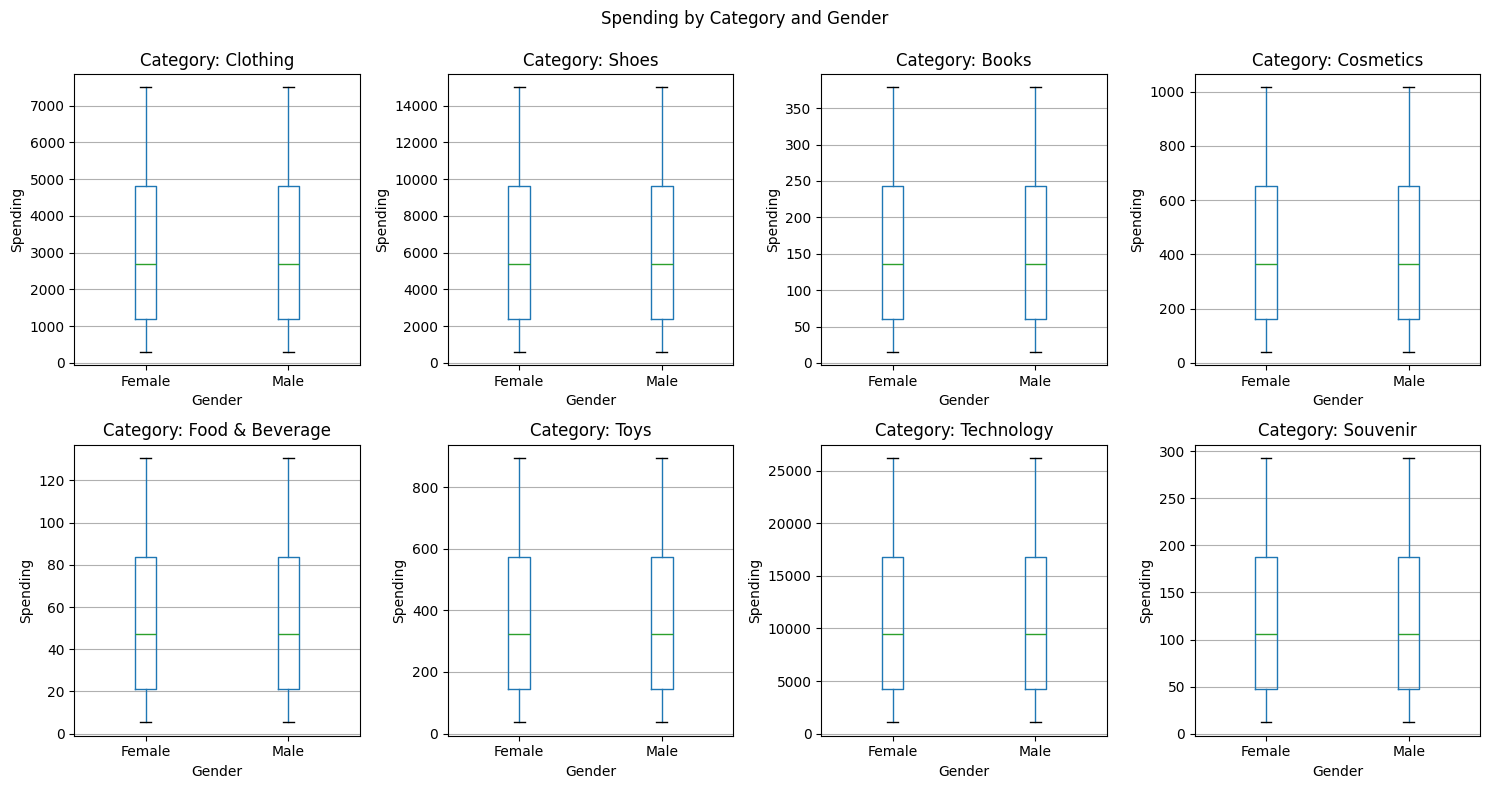

In [60]:
## I Used Chat GPT recomendation for the FOR as the code I used before fail due to some
# Label issue i could not understand why it was failing.
#I will create a different box plot for each category showing the spending by gender.
categories = cust_3['category'].unique()
num_categories = len(categories)
ncols = 4
nrows = 2
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4 * nrows))

axes = axes.flatten()
# Plot each category in a separate subplot
for ax, category in zip(axes, categories):
    subset = cust_3[cust_3['category'] == category]
    subset.boxplot(column='spending', by='gender', ax=ax)
    ax.set_title(f'Category: {category}')
    ax.set_xlabel('Gender')
    ax.set_ylabel('Spending')
    ax.grid(axis='x')

for ax in axes[len(categories):]:
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.suptitle('Spending by Category and Gender')
plt.show()

I can tell from the data that even the number of purchases differ for different gender by category
the measures of central tendency are almost the same for the spending.
Also there are no outliers for each group.

<Figure size 200x200 with 0 Axes>

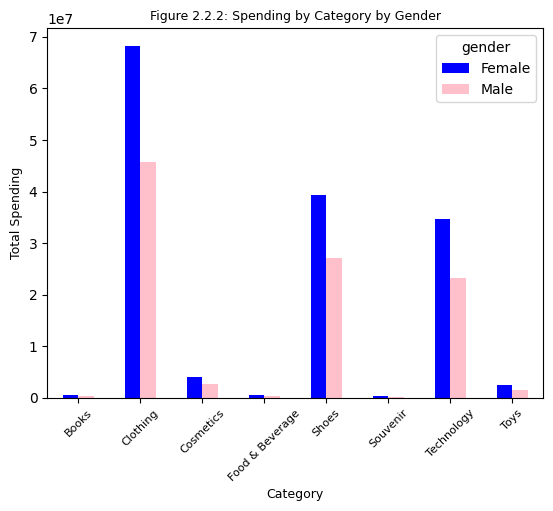

In [182]:
# I will take a look at the total spending by category and gender
plt.figure(figsize=(2, 2))
spending_category1 = cust_3.groupby(['category','gender'])['spending'].sum().unstack()
spending_category1.plot(kind='bar', color=['blue','pink'])
plt.xlabel('Category',fontsize=9)
plt.ylabel('Total Spending',fontsize=9)
plt.title('Figure 2.2.2: Spending by Category by Gender',fontsize=9)
plt.xticks(rotation=45,fontsize=8);
plt.show()

##### Conclusion 2.2

1. **Findings:**
   - From Figures 2.2.1 (Category and Category by Gender data frame descriptions), I can see that there are no outliers and no significant differences in spending between gend in each purchaseers.
   - From Figure 2.2.2 (Spending by Category by Gender), we can see that females spend more than males, but this is explained by the quantity of purchases.
   - On average, males and females buy similar quantities of products per purchase.
   - On average, males and females spend similar amounts per purchase.
   - Females make purchases more frequently.

2. **Conclusion:**
   The average spending per purchase is almost the same for females and males, but in total, females spend more because they also purchase more frequently.


#### 2.3. Create a scatter plot to visualise the relationship between age and spending. What insights can you derive from this visualization? Is there a correlation between age and spending?

In [65]:
cust_3.groupby('category')['spending'].unique() # Each category has only 5 spending values. 

category
Books               [242.4, 15.15, 60.6, 378.75, 136.35000000000002]
Clothing           [7502.0, 300.08, 1200.32, 2700.7200000000003, ...
Cosmetics                    [40.66, 1016.5, 365.94, 162.64, 650.56]
Food & Beverage                  [20.92, 47.07, 5.23, 130.75, 83.68]
Shoes                  [5401.53, 15004.25, 9602.72, 600.17, 2400.68]
Souvenir                      [293.25, 105.57, 46.92, 187.68, 11.73]
Technology                [26250.0, 16800.0, 4200.0, 9450.0, 1050.0]
Toys                          [573.44, 143.36, 322.56, 35.84, 896.0]
Name: spending, dtype: object

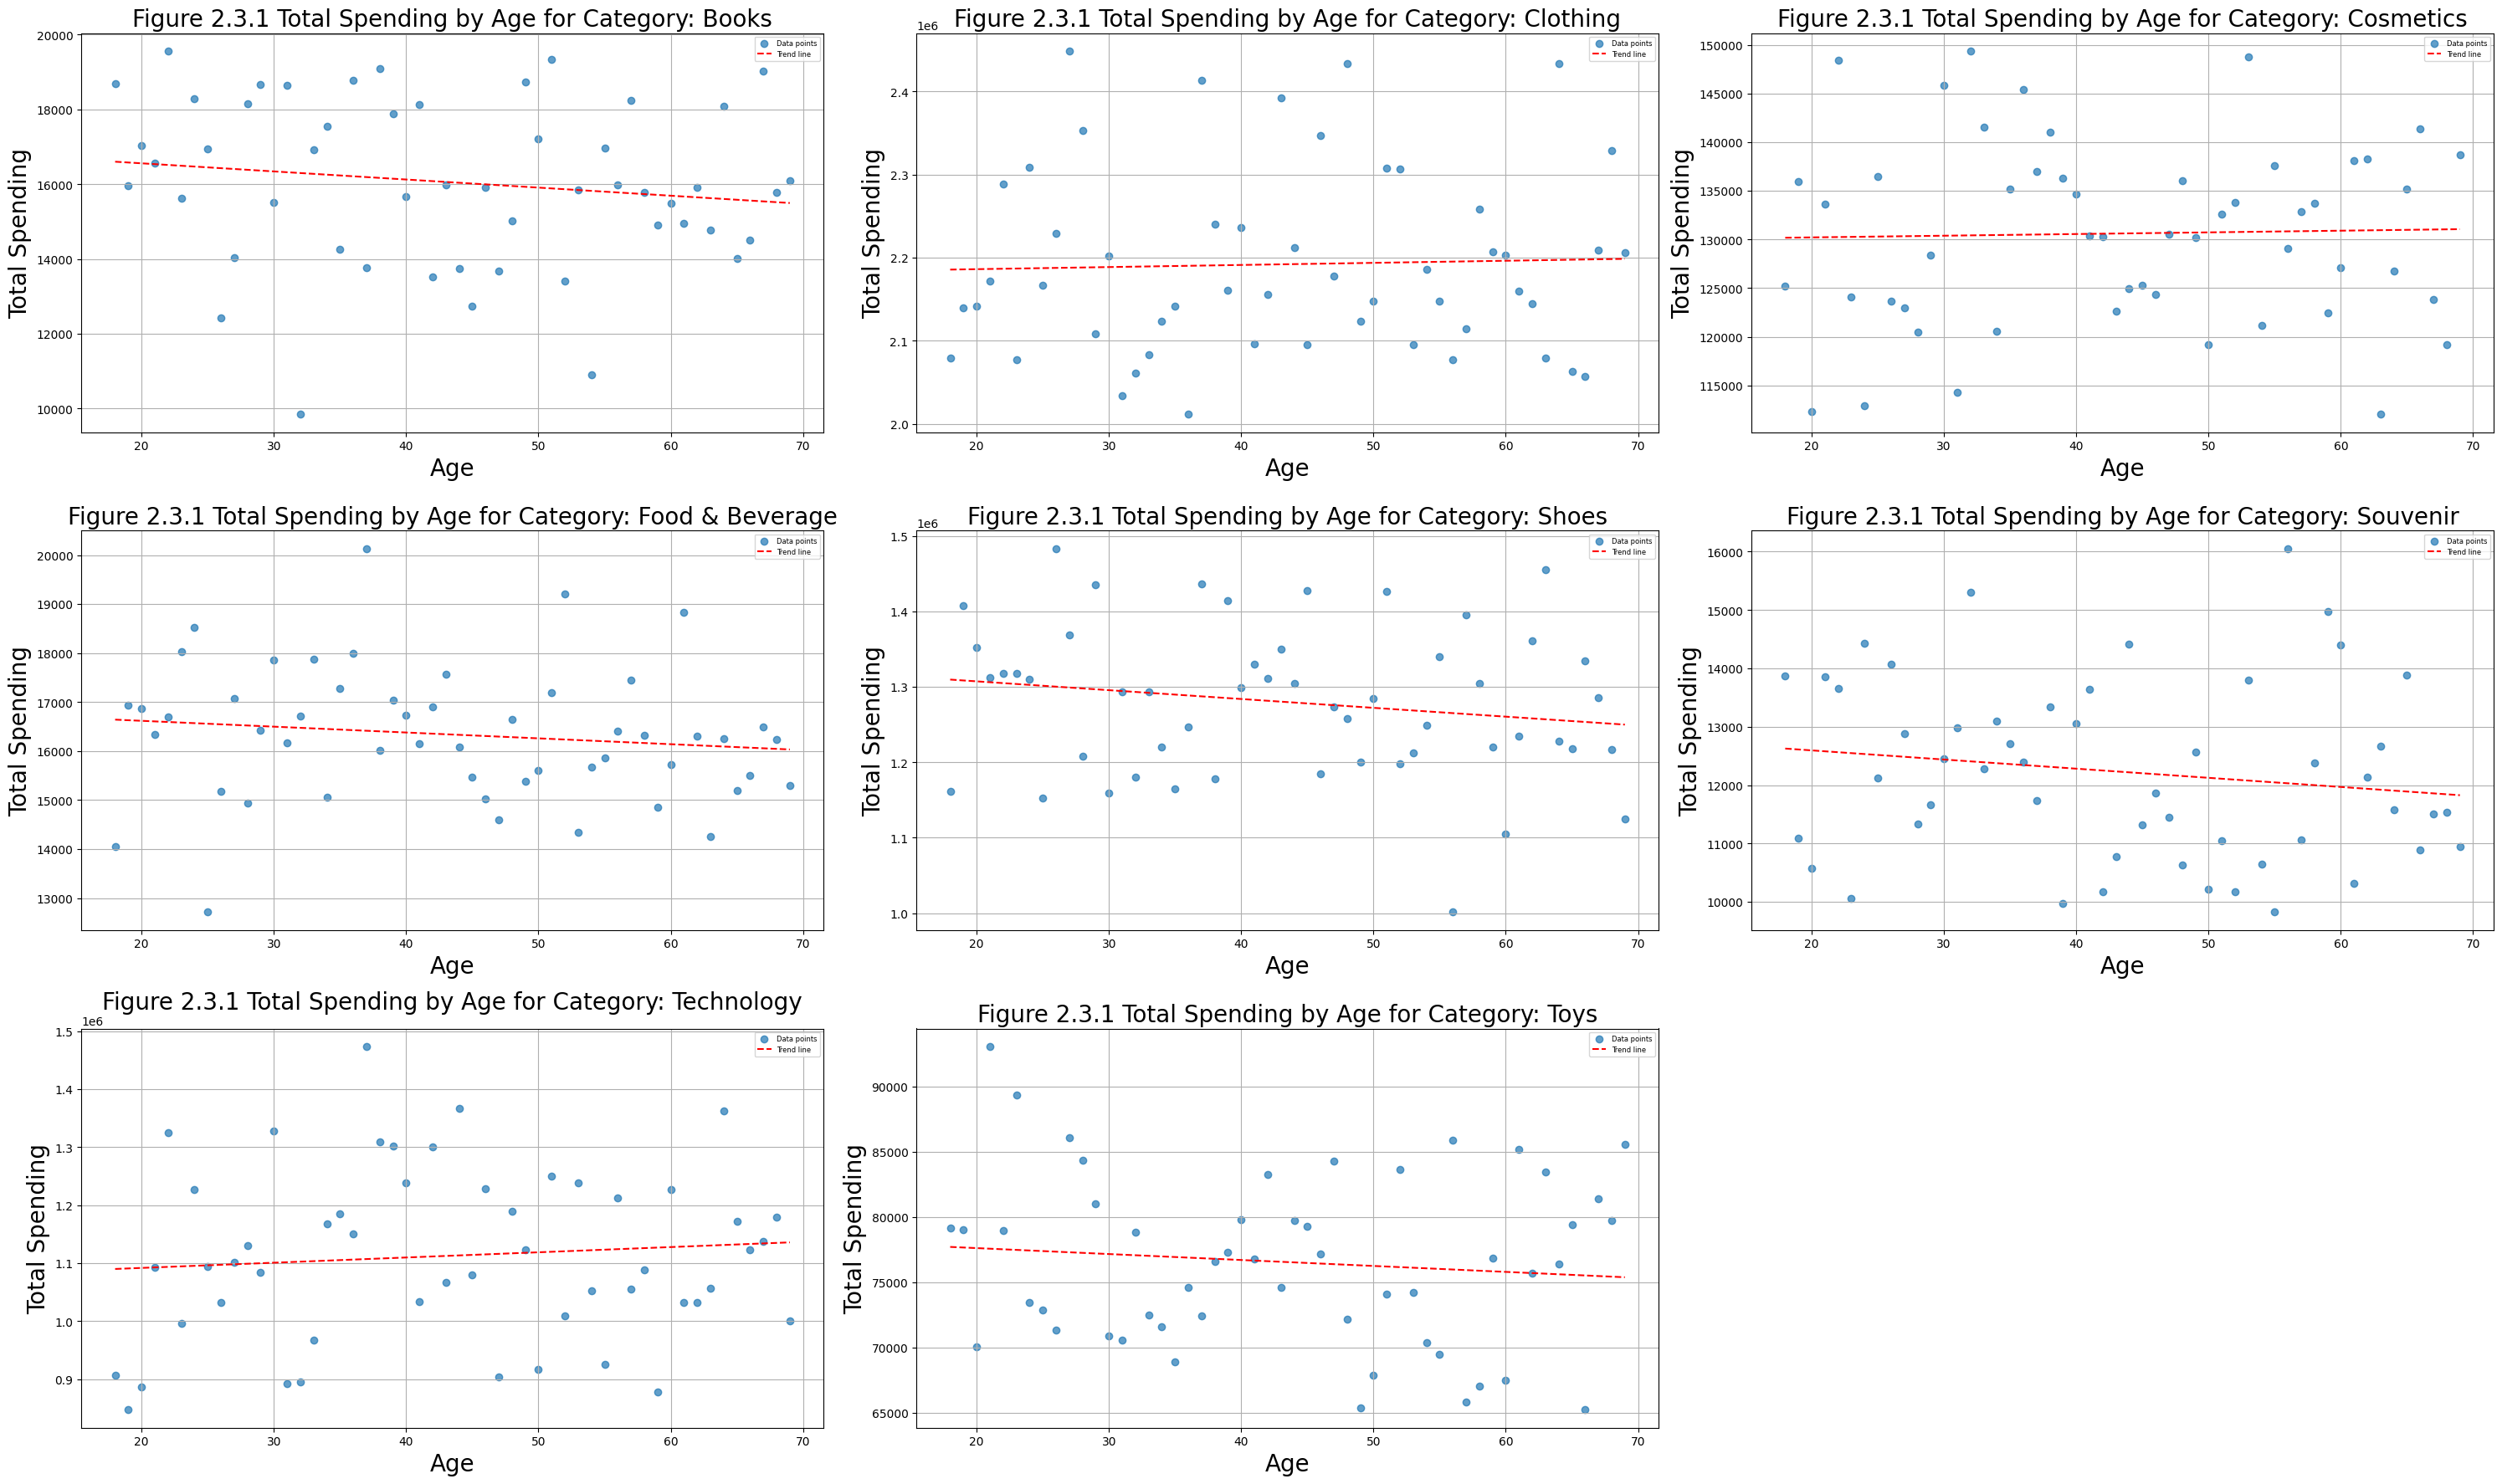

In [66]:
## I used Chat GPT to add a trend line
# Aggregate the data: total spending by age for each category
aggregated_data = cust_3.groupby(['category', 'age'])['spending'].sum().reset_index()
categories = aggregated_data['category'].unique()
ncols = 3
nrows = 3
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(30, 6 * nrows))
axes = axes.flatten()

# Plot each category in a separate subplot
for ax, category in zip(axes, categories):
    category_data = aggregated_data[aggregated_data['category'] == category]
    ax.scatter(category_data['age'], category_data['spending'], alpha=0.7, label='Data points')
    
    # Fit a linear regression line
    ages = category_data['age']
    spending = category_data['spending']
    coefficients = np.polyfit(ages, spending, 1)
    polynomial = np.poly1d(coefficients)
    age_range = np.linspace(ages.min(), ages.max(), 100)
    trend_line = polynomial(age_range)
    
    # Plot the trend line
    ax.plot(age_range, trend_line, color='red', linestyle='--', label='Trend line')
    ax.set_title(f'Figure 2.3.1 Total Spending by Age for Category: {category}', fontsize=20)
    ax.set_xlabel('Age', fontsize=20)
    ax.set_ylabel('Total Spending', fontsize=20)
    ax.grid(True)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.legend(fontsize=6)

# Hide any unused subplots
for ax in axes[len(categories):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [67]:
## From the plots I do not identify a clear relationship, i will calculate the correlation as I learned in Data Science Class
correlation_results = {}
for category in aggregated_data['category'].unique():
   
    category_data = aggregated_data[aggregated_data['category'] == category]
    correlation = category_data[['age', 'spending']].corr().loc['age', 'spending']
    correlation_results[category] = correlation

for category, correlation in correlation_results.items():
    print(f'{category} - Correlation: {correlation:.2f}')

Books - Correlation: -0.15
Clothing - Correlation: 0.03
Cosmetics - Correlation: 0.03
Food & Beverage - Correlation: -0.13
Shoes - Correlation: -0.18
Souvenir - Correlation: -0.15
Technology - Correlation: 0.09
Toys - Correlation: -0.11


##### **Conclusion 2.3**

1. **Findings:**
   - There are only 5 different prices per category
   - The scatter plots in Figure 2.3.2, "Total Spending by Age," show that there is no clear relationship between age and spending. The Shoes category might be the one where age affects spending the most, but even then, the correlation is small.
   - The trend by category does not indicate a clear correlation as all of them are close to 0

2. **Conclusion:**
   There is no clear relationship between the age and the spending across the different categories


#### 2.4 Segment the customers into different age groups (e.g., 18-25, 26-35, 36-45, 46-55, 56+). How does the spending score vary across these age groups? Provide a visualisation to support your analysis. (Aditional)


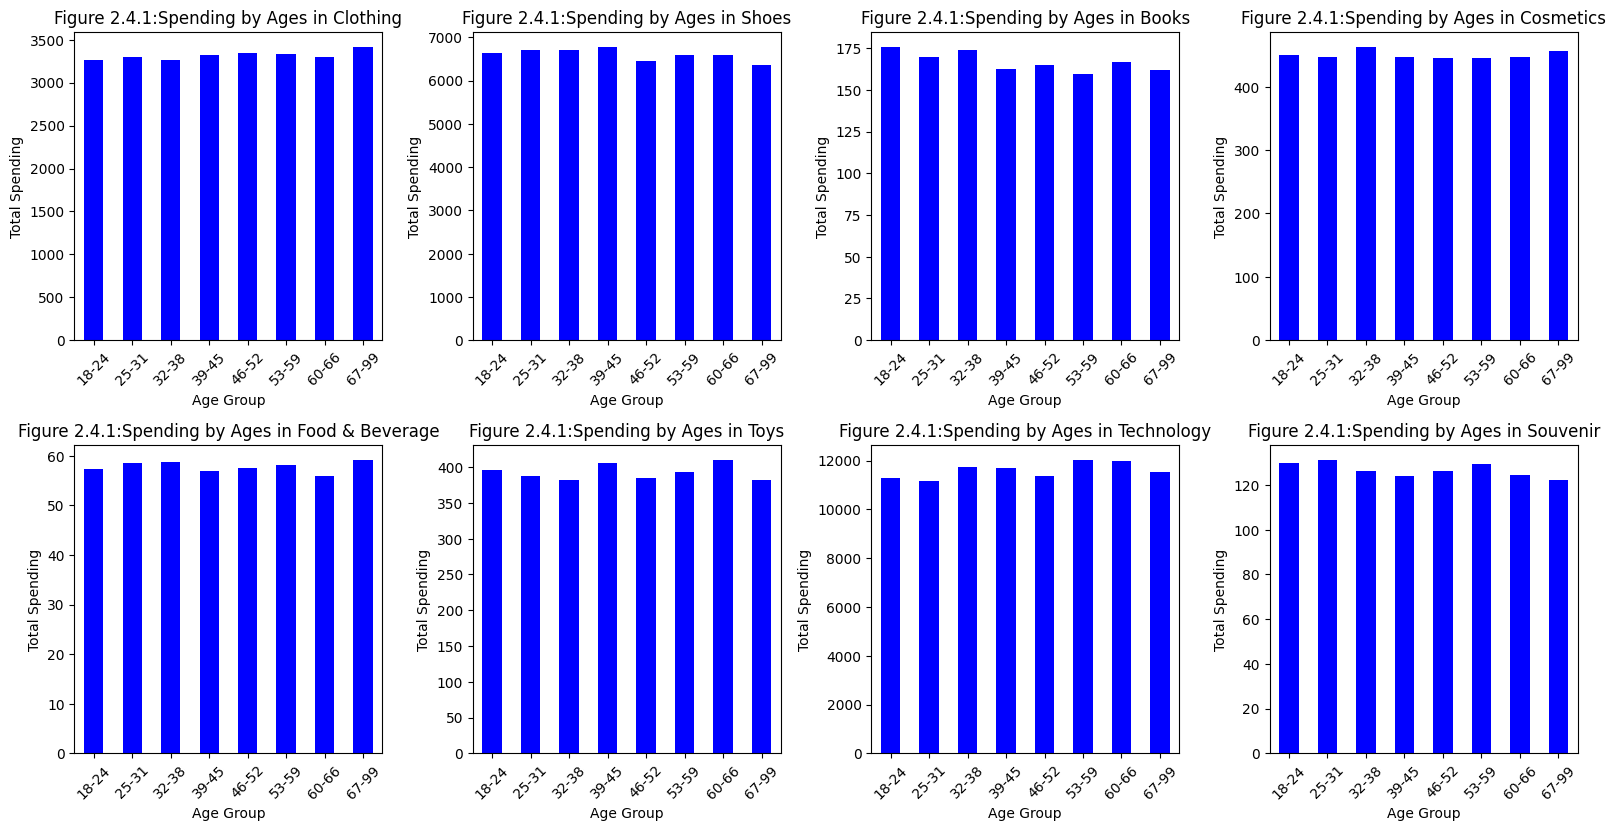

In [150]:
age_bins=[18,25,32,39,46,53,60,67,100] ## I created bins of 6 years lengh to show the average spending per bracket
age_labels=['18-24', '25-31', '32-38', '39-45', '46-52', '53-59', '60-66', '67-99']
cust_3['age_groups']=pd.cut(cust_3['age'],bins=age_bins,labels=age_labels);
categories = cust_3['category'].unique()
plt.figure(figsize=(16, 16))

for i, category in enumerate(categories, 1):
    plt.subplot(4, 4, i)
    cust_3_category = cust_3[cust_3['category'] == category]
    spending_age_group = cust_3_category.groupby('age_groups', observed=False)['spending'].mean();
    # observed=False to hide the warning message 
    spending_age_group.plot(kind='bar', color='blue')
    plt.xlabel('Age Group')
    plt.ylabel('Total Spending')
    plt.title(f'Figure 2.4.1:Spending by Ages in {category}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show();

##### **Conclusion 2.4 (aditional)**

1. **Findings** From figure 2.4.2:
   - There are not brackets where the spending is significantly diferent from others.
   - In cosmetics, for people between 32 and 38 years old the average spending is a bit higher than the other brackets.
   - In Technology, for ages over 32 the spending is slightly higer
  

2. **Conclusion:**
   There is no clear relationship between age brackets and the spending across the different categories

## **Section 3 Recommendations**
- Perform the following analysis and provide insights that you gained, what recommendations would you provide the business.

#### **3.1 Sales by Payment Method:**
Create a visualisation to visualize the proportion of total sales made by each payment_method. What can you infer from this visualisation about customer preferences for payment methods?


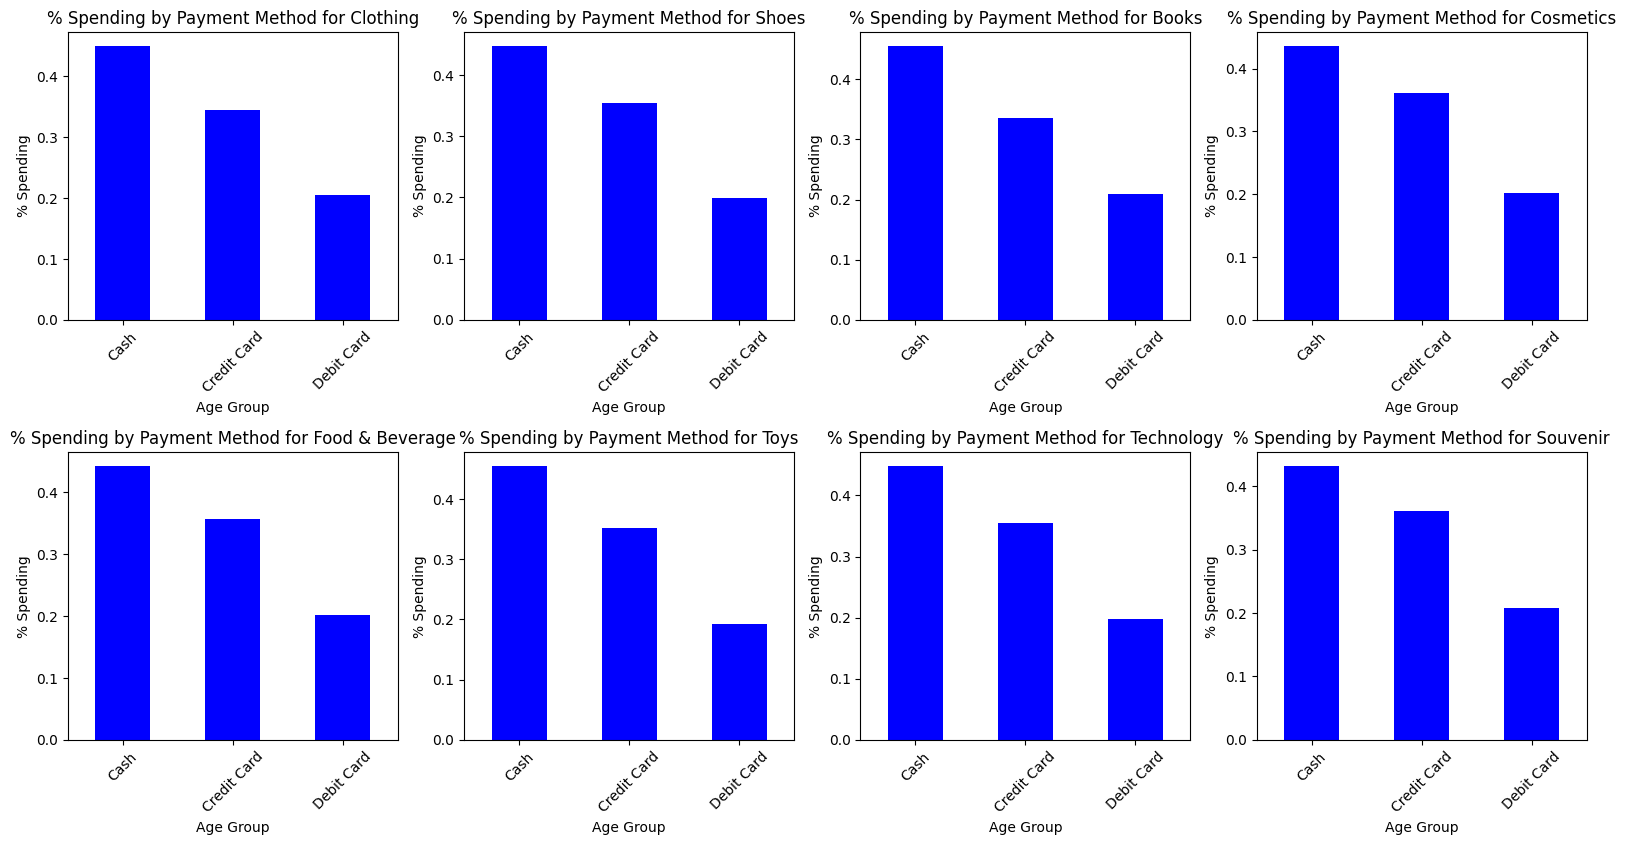

In [74]:
# First I will plot the proportion of spending by payment method per categories
plt.figure(figsize=(16, 16))

for i, category in enumerate(categories, 1):
    plt.subplot(4, 4, i) 
    cust_3_category = cust_3[cust_3['category'] == category]
    spending_payment_proportion = cust_3_category.groupby('payment_method')['spending'].sum()/cust_3_category['spending'].sum()
    spending_payment_proportion.plot(kind='bar', color='blue')
    plt.xlabel('Age Group')
    plt.ylabel('% Spending')
    plt.title(f'% Spending by Payment Method for {category}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [152]:
# Now I will take a look at the data numbers for top 3 categories. I will create a data frame to read it easily
results = pd.DataFrame(columns=['Category', 'Payment Method', 'Total Spending', 'Average Price', 'Total Quantity', 'Percentage of Purchases','average spending'])
categories=['Clothing', 'Shoes', 'Technology']
for category in categories:
    cust_3_category = cust_3[cust_3['category'] == category]
    group_by_payment = cust_3_category.groupby('payment_method').agg(
        total_spending=('spending', 'sum'),
        average_price=('price', 'mean'),
        total_quantity=('quantity', 'count'), # Purchases made
        average_spending=('spending', 'mean')
    ).reset_index()
    
    # Calculate the percentage of purchases for each payment method by category
    group_by_payment['Percentage of Purchases'] = (group_by_payment['total_quantity'] / group_by_payment['total_quantity'].sum()) * 100
    group_by_payment['Category'] = category
    
    # Append to results DataFrame
    results = pd.concat([results, group_by_payment], ignore_index=True)
results = results[['Category', 'payment_method', 'total_spending', 'average_price', 'total_quantity', 'Percentage of Purchases','average_spending']]
print(results);

     Category payment_method  total_spending  average_price  total_quantity  \
0    Clothing           Cash     51304077.44     903.599032         15455.0   
1    Clothing    Credit Card     39351590.96     895.298974         12025.0   
2    Clothing     Debit Card     23331520.08     905.380557          7005.0   
3       Shoes           Cash     29782836.08    1809.900232          4474.0   
4       Shoes    Credit Card     23560873.69    1810.645153          3553.0   
5       Shoes     Debit Card     13209741.70    1796.024425          2007.0   
6  Technology           Cash     25937100.00    3157.046980          2235.0   
7  Technology    Credit Card     20493900.00    3186.537365          1753.0   
8  Technology     Debit Card     11431350.00    3105.208333          1008.0   

   Percentage of Purchases  average_spending  
0                44.816587       3319.577964  
1                34.870233       3272.481577  
2                20.313180       3330.695229  
3                44.5


#### **Conclusion 3.1**

1. **Findings**:
   - The proportion of spending between payment methods is very similar across categories. Debit card payments account for up to 20% of the spending by category, while credit cards account for around 35%.
   - The number of purchases made with each payment method is almost the same for each category.
   - In all categories, the preferred method of payment is cash, followed by credit cards, with debit cards being the least preferred.
   - The average price paid by payment method in each category is very similar.
   - The primary difference lies in the number of purchases made with the different payment methods.

2. **Recommendation**:
   - Since the average spending on technology is higher than in other categories, but the number of purchases is not among the top three categories, my recommendation is to invest in marketing campaigns for this category.
   - As the average price paid with a credit card is slightly higher, focusing the marketing campaign on this payment method could attract more buyers and generate higher spending through credit card purchases.

#### 3.2 Sales Trend Over Time:
Create a line chart to visualize the total monthly sales over the period covered by the dataset. Provide insights into any trends or patterns you observe.

I will focus only in the 3 greatest spending categories

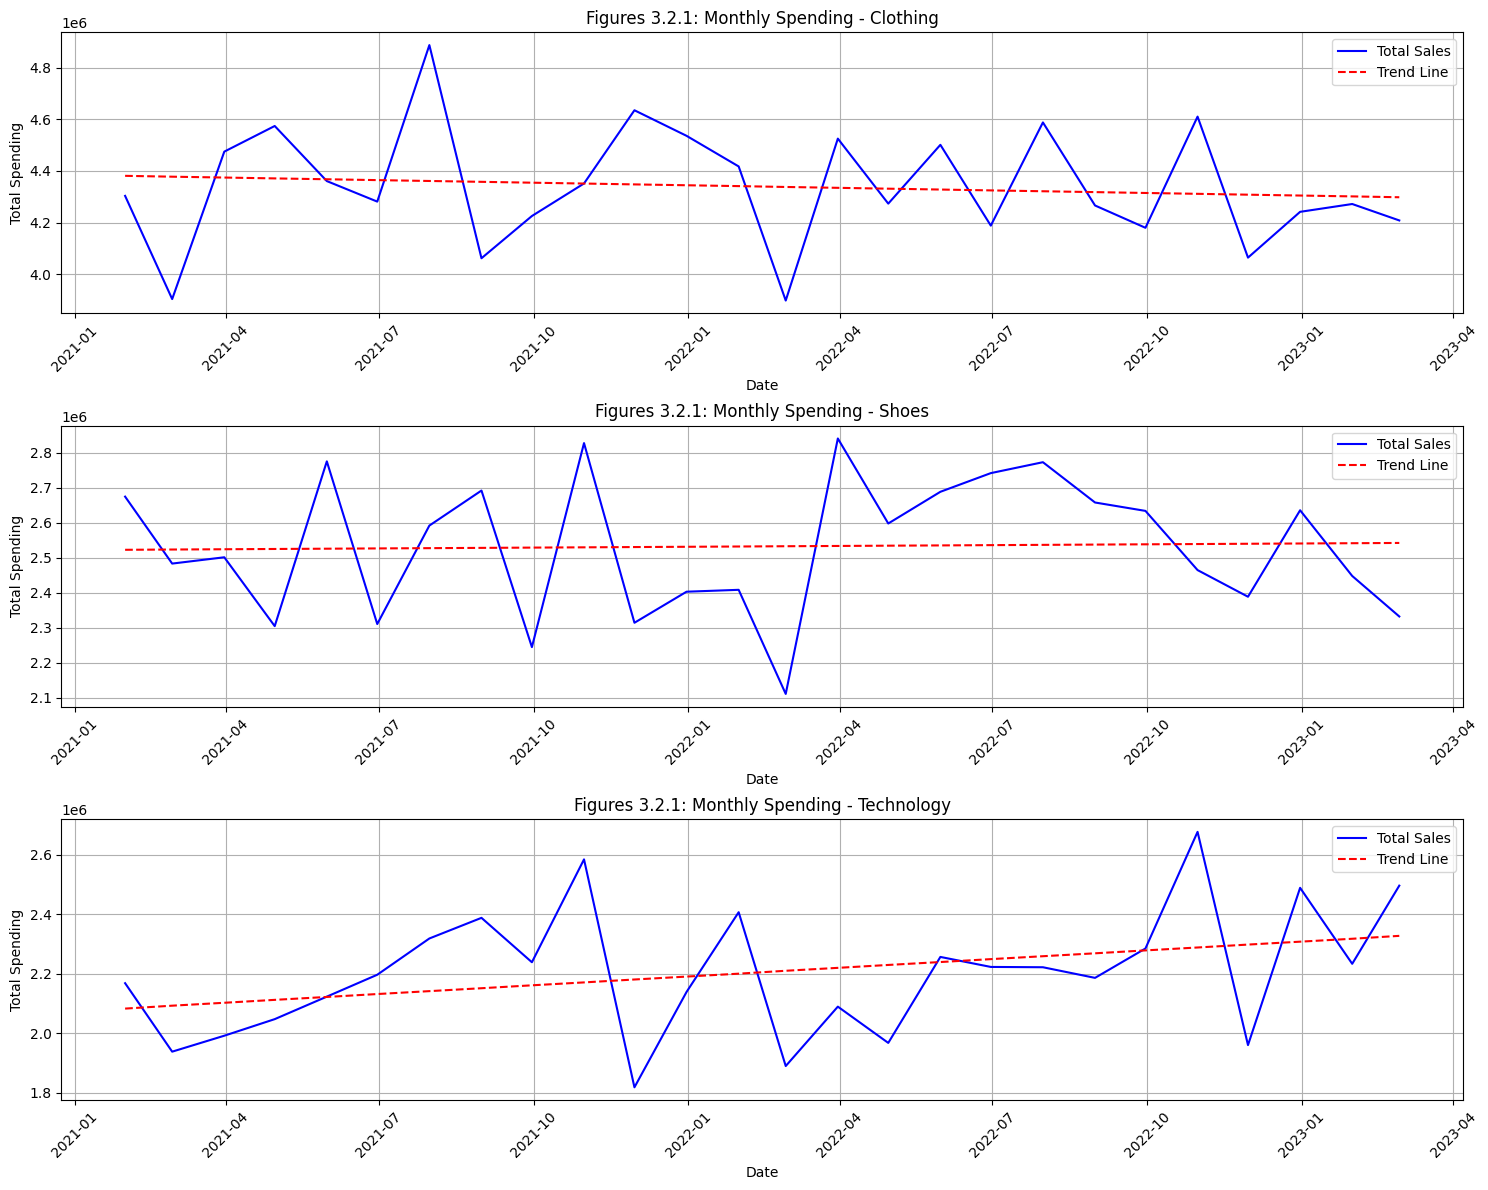

In [166]:
# I used ChatGPT to add a trend line to each plot.
#cust_3=cust_3.set_index('date')
n_categories = len(categories)
n_cols = 1
n_rows = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows), sharex=False)
axes = axes.flatten() 

for i, category in enumerate(categories):
    category_data = cust_3[cust_3['category'] == category]
    monthly_sales = category_data['spending'].resample('ME').sum()
# I eliminated the march 2023 data as there are only 8 days and i'm analyzing total per month.  
    if not monthly_sales.empty:
        last_month = monthly_sales.index[-1]
        monthly_sales = monthly_sales[monthly_sales.index < last_month]
    
    axes[i].plot(monthly_sales.index, monthly_sales.values, linestyle='-', color='blue', label='Total Sales')
    # Add a trend line
    x = np.arange(len(monthly_sales))
    y = monthly_sales.values
    z = np.polyfit(x, y, 1)  # Fit a linear trend line (1st degree polynomial)
    p = np.poly1d(z)
    axes[i].plot(monthly_sales.index, p(x), linestyle='--', color='red', label='Trend Line')
    axes[i].set_title(f'Figures 3.2.1: Monthly Spending - {category}')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Total Spending')
    axes[i].grid(True)
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)): # Remove un used plots
    fig.delaxes(axes[j])

plt.tight_layout()
plt.subplots_adjust(hspace=0.4, wspace=0.2)
plt.show()

Now I will plot the spending by year to understand if there are any seasonalities

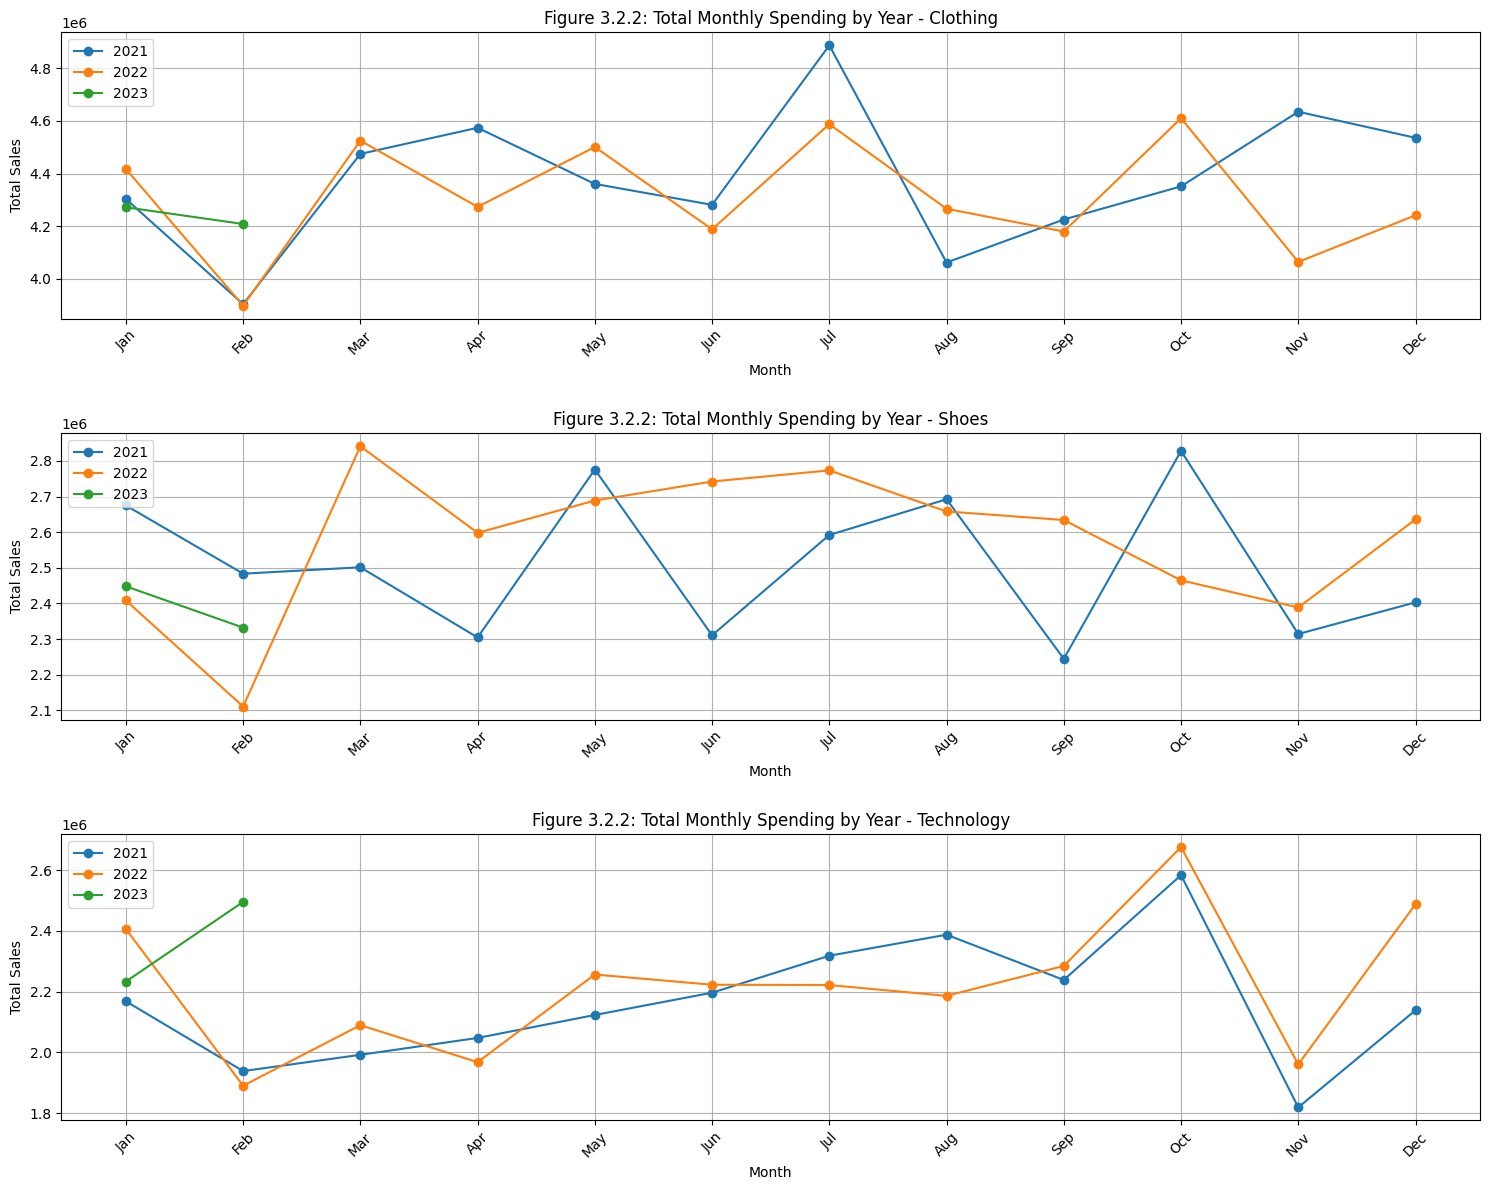

In [168]:
n_categories = 3
n_cols = 1
n_rows = 3  
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows), sharex=False)
axes = axes.flatten()

for i, category in enumerate(categories):
    category_data = cust_3[cust_3['category'] == category]
    
    # Eliminate data for the last month
    last_date = category_data.index.max()
    last_month = last_date.month
    last_year = last_date.year
    category_data = category_data[(category_data.index.month != last_month) | (category_data.index.year != last_year)]
    category_data['year'] = category_data.index.year
    category_data['month'] = category_data.index.month
    monthly_data = category_data.groupby(['year', 'month']).agg({
        'spending': 'sum'
    }).unstack(level=0)

    # Plot for each year
    for year in monthly_data.columns.levels[1]:
        axes[i].plot(monthly_data.index, monthly_data['spending', year], marker='o', label=str(year))
    
    axes[i].set_title(f'Figure 3.2.2: Total Monthly Spending by Year - {category}')
    axes[i].set_xlabel('Month')
    axes[i].set_ylabel('Total Sales')
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    axes[i].grid(True)
    axes[i].legend(loc='upper left')
    axes[i].tick_params(axis='x', rotation=45)

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.subplots_adjust(hspace=0.4, wspace=0.2)
plt.show()


#### **Conclusion 3.2**
1. **Findings:**
    1. From figure 3.2.1
       1. For Clothing, the trend is negative, indicating that spending is decreasing.
       2. For Shoes, spending appears stable with some highs and lows.
       3. For Technology, spending seems to be increasing over time.
    2. From figure 3.2.2
        1. In 2021, Shoes experienced many highs and lows, but in 2022, spending became more stable.
        2. For Technology, the trend is positive from February to October, but there is a notable drop in spending in November for two consecutive years. However, 2023 started positively, with February spending higher than in the previous two years.
  
2. **Recommendations:**

- Since Clothing spending is decreasing over time and it's the largest spending category, the business should invest in marketing to reverse this trend. It would be beneficial to analyze what happened in July 2021, the peak spending month, and see if those conditions can be replicated.
- For Technology, the business should investigate why spending drops in November for the past two years. It might be useful to check if other retail companies are running marketing campaigns during that time so that the business can plan accordingly for November.
- Additionally, understanding whether the February 2023 sales increase in Technology was driven by a marketing campaign could provide insights into effective strategies, suggesting that the business should continue with similar approaches as they are proving successful.